# Эксперименты с моделями СР2

Минимум 4–5 моделей + ансамбли, перебор гиперпараметров, обоснование финальной модели,
эксперименты с уменьшением размерности.

## Действия
1. Загрузка очищенного датасета из `02_baseline` (тот же `vacancies_clean.parquet`, тот же `SEED`)
2. Воспроизводимый сплит train/val/test стратификация по бинам log1p(salary)
3. Препроцессинг через `ColumnTransformer` числовые - `StandardScaler`, категориальные - `OneHotEncoder`, текст (название вакансии) - `TfidfVectorizer`
4. Обёртка `TransformedTargetRegressor` — учим модель на `log1p(y)`, метрики считаем в рублях
5. Эксперименты
   - baseline `Ridge` (для сверки с 02_baseline)
   - RandomForest + RandomizedSearchCV
   - SVM (`LinearSVR`) + GridSearchCV
   - CatBoost + RandomizedSearchCV
   - эксперимент с уменьшением размерности (TruncatedSVD)
6. Сводная таблица экспериментов на val
7. Финальная модель... оценка на test, сохранение в папку

## Главная метрика
`MAE` в рублях — основная. Дополнительно `RMSE` и `R²` для сравнения.
Все метрики считаются после `expm1` (возврат из log-пространства)

## 1. Импорты и настройки

In [1]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import loguniform, randint
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

from catboost import CatBoostRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_IMG = PROJECT_ROOT / "report" / "images"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_IMG.mkdir(parents=True, exist_ok=True)

TARGET = "salary_mid_rub"
DATA_PATH = DATA_PROCESSED / "vacancies_clean.parquet"
assert DATA_PATH.exists(), (
    f"Не найден {DATA_PATH}. Сначала пройти 01_eda.ipynb — он сохраняет vacancies_clean.parquet"
)

## 2. Загрузка данных и сплит

Воспроизводим тот же сплит, что и в 01_eda - 02_baseline. Стратификация по бинам `log1p(salary)`,
чтобы хвосты распределения попали во все три выборки

In [2]:
df = pd.read_parquet(DATA_PATH)

In [3]:
TARGET = "salary_mid_rub"

print("Статистика таргета")
print(df[TARGET].describe())

Статистика таргета
count     15355.000000
mean      99272.713399
std       51221.402796
min       10000.000000
25%       62640.000000
50%       87000.000000
75%      121800.000000
max      300000.000000
Name: salary_mid_rub, dtype: float64


In [4]:
print("Исключаем из фичей", [TARGET])
feature_cols = [c for c in df.columns if c not in [TARGET]]
print(f"Итого фичей {len(feature_cols)}")

Исключаем из фичей ['salary_mid_rub']
Итого фичей 15


In [5]:
salary_bins = pd.qcut(np.log1p(df[TARGET]), q=10, labels=False, duplicates="drop")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=salary_bins,
)
temp_bins = salary_bins.loc[temp_df.index]

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_bins,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values

print(f"train {len(train_df):>7,}  ({len(train_df) / len(df):.1%})")
print(f"val {len(val_df):>7,}  ({len(val_df) / len(df):.1%})")
print(f"test {len(test_df):>7,}  ({len(test_df) / len(df):.1%})")

train  10,748  (70.0%)
val   2,303  (15.0%)
test   2,304  (15.0%)


## 3. Группировка фичей

Группы те же, что зафиксировали в EDA. Заодно отсекаем колонки с очевидным data leakage
(`salary_from_rub`, `salary_to_rub` — из них считается таргет) и идентификаторы.

In [6]:
id_cols = [c for c in ["id"] if c in X_train.columns]

text_cols = [c for c in ["name", "description"] if c in X_train.columns]
list_cols = [
    c for c in ["key_skills", "professional_role_ids", "professional_role_names"]
    if c in X_train.columns
]

datetime_cols = [
    c for c in X_train.columns
    if pd.api.types.is_datetime64_any_dtype(X_train[c])
]

bool_cols = list(X_train.select_dtypes(include="bool").columns)
id_like_num_cols = [
    c for c in X_train.columns
    if c.endswith("_id") and c != "id" and pd.api.types.is_numeric_dtype(X_train[c])
]

num_cols = [
    c for c in X_train.select_dtypes(include=[np.number]).columns
    if c not in id_like_num_cols
]

cat_cols = [
    c for c in X_train.columns
    if c not in (
        id_cols + text_cols + list_cols + datetime_cols
        + bool_cols + num_cols + id_like_num_cols
    )
]
drop_cols = id_cols + id_like_num_cols + datetime_cols

# страховка ... таргет не должен оказаться ни в одной из групп фичей
assert TARGET not in num_cols + cat_cols + bool_cols + text_cols + list_cols, \
    f"Таргет {TARGET} попал в фичи ... проверь сборку колонок"

print("text_cols", text_cols)
print("list_cols", list_cols)
print("bool_cols", bool_cols)
print("num_cols", num_cols)
print("cat_cols", cat_cols)
print("drop_cols", drop_cols)

text_cols ['name', 'description']
list_cols ['key_skills', 'professional_role_ids', 'professional_role_names']
bool_cols ['has_test', 'response_letter_required']
num_cols ['key_skills_count']
cat_cols ['area_id', 'area_name', 'employer_name', 'employer_id', 'experience', 'experience_name']
drop_cols ['id']


## 4. Препроцессинг

`ColumnTransformer` с тремя ветками
- числовые - median-импутация + `StandardScaler`,
- категориальные - impute-константа + `OneHotEncoder(handle_unknown="ignore")` (защита от новых значений в val/test),
- текст (`name`) - `TfidfVectorizer` (ngram 1–2, ограниченный словарь).

У бустинга и деревьев StandardScaler не нужен, но мешать не будет — зато один пайплайн на все модели

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

In [8]:
class ListToStringTransformer(BaseEstimator, TransformerMixin):
    """Превращает колонку со списками строк в одну строку через пробел.
    Нужно, чтобы потом скормить это TfidfVectorizer'у"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X.ravel() if hasattr(X, "ravel") else X)
        return s.apply(self._join).values

    @staticmethod
    def _join(x):
        if x is None:
            return ""
        if isinstance(x, float) and np.isnan(x):
            return ""
        try:
            return " ".join(str(item) for item in x)
        except TypeError:
            return str(x)


class TextConcatTransformer(BaseEstimator, TransformerMixin):
    """Склеивает несколько текстовых колонок в одну строку"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.fillna("").astype(str).agg(" ".join, axis=1).values

In [9]:
class BoolToFloatTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.astype(float).values


numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=20,
        sparse_output=True,
    )),
])

bool_pipe = Pipeline(steps=[
    ("to_float", BoolToFloatTransformer()),
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

text_pipe = Pipeline(steps=[
    ("concat", TextConcatTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 1),
        min_df=5,
        sublinear_tf=True,
    )),
])

skills_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=2_000,
        token_pattern=r"[^\s][^\s]*",
        min_df=3,
        sublinear_tf=True,
    )),
])

roles_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=500,
        token_pattern=r"[^\s][^\s]*",
        min_df=2,
    )),
])

transformers = []
if num_cols:
    transformers.append(("num", numeric_pipe, num_cols))
if cat_cols:
    transformers.append(("cat", categorical_pipe, cat_cols))
if bool_cols:
    transformers.append(("bool", bool_pipe, bool_cols))
if text_cols:
    transformers.append(("text", text_pipe, text_cols))
if "key_skills" in list_cols:
    transformers.append(("skills", skills_pipe, "key_skills"))
if "professional_role_names" in list_cols:
    transformers.append(("roles", roles_pipe, "professional_role_names"))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3,
)

print(f"Преобразований в ColumnTransformer ... {len(transformers)}")
for name, _, cols in transformers:
    cols_repr = cols if isinstance(cols, str) else f"{len(cols)} cols"
    print(f"  - {name:8s} -> {cols_repr}")

Преобразований в ColumnTransformer ... 6
  - num      -> 1 cols
  - cat      -> 6 cols
  - bool     -> 2 cols
  - text     -> 2 cols
  - skills   -> key_skills
  - roles    -> professional_role_names


## 5. Метрики и обёртка для логирования

Учимся на `log1p(y)`, метрики считаем после `expm1` — в рублях. Так:
- ошибки в нижнем хвосте (зарплаты в десятки тыс.) и в верхнем (миллионы) попадают в одну шкалу;
- MAE интерпретируется как «в среднем модель ошибается на N руб.».

In [10]:
def evaluate(y_true_rub, y_pred_rub):
    """Считает метрики в рублях. ОБА аргумента должны быть в рублях"""
    y_pred = np.clip(y_pred_rub, 10_000, None)
    return {
        "MAE": float(mean_absolute_error(y_true_rub, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true_rub, y_pred))),
        "R2": float(r2_score(y_true_rub, y_pred)),
    }

In [11]:
def wrap_log_target(estimator):
    """Учит модель на log1p(y), при предсказании возвращает рубли через expm1"""
    return TransformedTargetRegressor(
        regressor=estimator,
        func=np.log1p,
        inverse_func=np.expm1,
    )
experiments: list[dict] = []

def log_experiment(
    name: str,
    pipeline: Pipeline,
    fit_seconds: float,
    best_params: dict | None = None,
    notes: str = "",
) -> dict:
    """Считает метрики на train/val и кладёт всё в общий список экспериментов."""
    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    train_metrics = evaluate(y_train, pred_train)
    val_metrics = evaluate(y_val, pred_val)
    row = {
        "model": name,
        "fit_sec": round(fit_seconds, 1),
        "train_MAE": round(train_metrics["MAE"], 0),
        "val_MAE": round(val_metrics["MAE"], 0),
        "val_RMSE": round(val_metrics["RMSE"], 0),
        "val_R2": round(val_metrics["R2"], 3),
        "best_params": best_params or {},
        "notes": notes,
    }
    experiments.append(row)
    print(f"[{name}] val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | R2={row['val_R2']:.3f} | {row['fit_sec']}s")
    return row

## 6. Эксперимент 1 — Ridge (sanity-check baseline)

Простая линейная модель с теми же фичами должна дать качество, близкое к baseline
из 02_baseline. Если резко лучше или хуже — значит сплит/препроцессинг где-то поехали

In [12]:
ridge_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(Ridge(alpha=1.0, random_state=SEED))),
])

t0 = time.perf_counter()
ridge_pipe.fit(X_train, y_train)
log_experiment(
    name="Ridge (new data)",
    pipeline=ridge_pipe,
    fit_seconds=time.perf_counter() - t0,
    notes="Ridge на тех же фичах, что и в CP1... Нужен для сверки",
)

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


[Ridge (new data)] val MAE=  22,190 | RMSE=  32,496 | R2=0.606 | 1.1s


{'model': 'Ridge (new data)',
 'fit_sec': 1.1,
 'train_MAE': 13614.0,
 'val_MAE': 22190.0,
 'val_RMSE': 32496.0,
 'val_R2': 0.606,
 'best_params': {},
 'notes': 'Ridge на тех же фичах, что и в CP1... Нужен для сверки'}

## 7. Эксперимент 2 — RandomForest + RandomizedSearchCV

**Гипотеза.** RandomForest умеет ловить нелинейности и взаимодействия фичей, должен опередить Ridge.

**Как проверяем.** RandomizedSearchCV по сетке `n_estimators / max_depth / min_samples_leaf / max_features`,
5 итераций × 3 фолда. RandomizedSearch вместо Grid — потому что комбинаций много, а время дорого.

**Поиск делается только на train**, val вообще не светится — это защищает от подсматривания.

In [13]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(
        RandomForestRegressor(random_state=SEED, n_jobs=-1)
    )),
])

rf_param_dist = {
    "model__regressor__max_depth": [20, 30, 40, None],
    "model__regressor__min_samples_leaf": [1, 2, 3, 5],
    "model__regressor__max_features": [0.1, 0.3, "sqrt"],
    "model__regressor__min_samples_split": [2, 5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=6,
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=SEED,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_seconds = time.perf_counter() - t0

rf_best = rf_search.best_estimator_
log_experiment(
    name="RandomForest + RandomizedCV",
    pipeline=rf_best,
    fit_seconds=rf_seconds,
    best_params={
        k.replace("model__regressor__", ""): v
        for k, v in rf_search.best_params_.items()
    },
    notes="5 итераций на 3 фолда, scoring=neg_MAE на log-шкале",
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[RandomForest + RandomizedCV] val MAE=  24,382 | RMSE=  36,324 | R2=0.507 | 92.2s


{'model': 'RandomForest + RandomizedCV',
 'fit_sec': 92.2,
 'train_MAE': 9456.0,
 'val_MAE': 24382.0,
 'val_RMSE': 36324.0,
 'val_R2': 0.507,
 'best_params': {'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 0.3,
  'max_depth': None},
 'notes': '5 итераций на 3 фолда, scoring=neg_MAE на log-шкале'}

## 8. Эксперимент 3 — SVM (LinearSVR) + GridSearchCV

**Гипотеза.** На разреженных фичах (OHE + tf-idf) ядерный SVR станет считаться часами, а вот
линейный (`LinearSVR`) масштабируется и иногда выигрывает у Ridge за счёт robust-лосса (epsilon-insensitive).

**Как проверяем.** GridSearchCV по компактной сетке `C / epsilon`, 3 фолда.
На log-таргете шкала уже нормализована, выбросов меньше → SVM не должен взорваться.

Для устойчивости и скорости передаём `dual="auto"` и `max_iter=5000`.

In [34]:
svm_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(
        LinearSVR(random_state=SEED, dual="auto", max_iter=5000)
    )),
])

svm_param_grid = {
    "model__regressor__C": [0.1, 1.0, 5.0],
    "model__regressor__epsilon": [0.0, 0.05, 0.1],
}

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
svm_seconds = time.perf_counter() - t0

svm_best = svm_search.best_estimator_
log_experiment(
    name="LinearSVR + GridSearchCV",
    pipeline=svm_best,
    fit_seconds=svm_seconds,
    best_params={
        k.replace("model__regressor__", ""): v
        for k, v in svm_search.best_params_.items()
    },
)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

[LinearSVR + GridSearchCV] val MAE=  22,196 | RMSE=  32,943 | R2=0.595 | 26.0s


{'model': 'LinearSVR + GridSearchCV',
 'fit_sec': 26.0,
 'train_MAE': 16339.0,
 'val_MAE': 22196.0,
 'val_RMSE': 32943.0,
 'val_R2': 0.595,
 'best_params': {'C': 0.1, 'epsilon': 0.05},
 'notes': ''}

## 9. CatBoost
История запусков
| № | depth | lr  | iterations | bestTest | bestIteration |
|---|-------|-----|------------|----------|---------------|
| 1 | 6     |0.05 | 1000       | 0.328353 | 999 |
| 2 | 8     |0.03 | 2000       | 0.320812 | 1999 |

Вариант 3:
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
[CatBoost] train MAE=  15,216 | val MAE=  25,467 | RMSE=  46,833 | R2=0.498 | 432.8s

Вариант 4
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=10.0,
    bagging_temperature=1.0,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
[CatBoost] train MAE=  18,013 | val MAE=  25,708 | RMSE=  47,143 | R2=0.491 | 138.2s

Вариант 5
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    random_strength=1.0,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
[CatBoost] train MAE=  18,123 | val MAE=  25,817 | RMSE=  47,218 | R2=0.489 | 137.8s

In [14]:
from catboost import CatBoostRegressor, Pool

In [15]:
# готовим фичи под CatBoost ... категории строкой, списки через пробел, тексты как есть
def prep_for_catboost(df_):
    df_ = df_.copy()
    # категории ... оставляем только _name (без _id-дублей), приводим к строке
    cats = ["area_name", "employer_name", "experience_name"]
    for c in cats:
        df_[c] = df_[c].astype(str).fillna("missing")

    # списки ... склеиваем в строку через пробел
    for c in ["key_skills", "professional_role_names"]:
        df_[c] = df_[c].apply(
            lambda x: " ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else ""
        )

    # тексты ... NaN -> ""
    for c in ["name", "description"]:
        df_[c] = df_[c].fillna("").astype(str)

    # булевы ... в int
    for c in ["has_test", "response_letter_required"]:
        df_[c] = df_[c].astype(float).fillna(0).astype(int)

    # числовые ... median
    df_["key_skills_count"] = df_["key_skills_count"].fillna(df_["key_skills_count"].median())

    keep = cats + ["key_skills", "professional_role_names",
                   "name", "description",
                   "has_test", "response_letter_required",
                   "key_skills_count"]
    return df_[keep]

In [16]:
X_train_cb = prep_for_catboost(X_train)
X_val_cb = prep_for_catboost(X_val)
X_test_cb = prep_for_catboost(X_test)

cat_features = ["area_name", "employer_name", "experience_name"]
text_features = ["name", "description", "key_skills", "professional_role_names"]

In [17]:
# учим CatBoost ... в log-шкале, с early stopping по val
t0 = time.perf_counter()

cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    random_strength=1.0,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)

cb_best.fit(
    Pool(X_train_cb, np.log1p(y_train),
         cat_features=cat_features, text_features=text_features),
    eval_set=Pool(X_val_cb, np.log1p(y_val),
                  cat_features=cat_features, text_features=text_features),
)

cb_seconds = time.perf_counter() - t0

def predict_rub(model, X_df):
    return np.clip(np.expm1(model.predict(X_df)), 10_000, None)

train_metrics = evaluate(y_train, predict_rub(cb_best, X_train_cb))
val_metrics = evaluate(y_val, predict_rub(cb_best, X_val_cb))

row = {
    "model": "CatBoost (native)",
    "fit_sec": round(cb_seconds, 1),
    "train_MAE": round(train_metrics["MAE"], 0),
    "val_MAE": round(val_metrics["MAE"], 0),
    "val_RMSE": round(val_metrics["RMSE"], 0),
    "val_R2": round(val_metrics["R2"], 3),
    "best_params": {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3.0,
                    "iterations_used": cb_best.tree_count_},
    "notes": "категории и тексты нативно, early stopping на val",
}
experiments.append(row)
print(f"\n[CatBoost] train MAE={row['train_MAE']:>8,.0f} | "
      f"val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | "
      f"R2={row['val_R2']:.3f} | {row['fit_sec']}s")

0:	learn: 0.3883954	test: 0.3925284	best: 0.3925284 (0)	total: 90.8ms	remaining: 7m 33s
200:	learn: 0.2774991	test: 0.2792425	best: 0.2792425 (200)	total: 5.79s	remaining: 2m 18s
400:	learn: 0.2575387	test: 0.2626807	best: 0.2626807 (400)	total: 11.2s	remaining: 2m 8s
600:	learn: 0.2464859	test: 0.2550168	best: 0.2550168 (600)	total: 16.7s	remaining: 2m 2s
800:	learn: 0.2387906	test: 0.2510911	best: 0.2510911 (800)	total: 22.1s	remaining: 1m 55s
1000:	learn: 0.2325970	test: 0.2484675	best: 0.2484640 (999)	total: 27.5s	remaining: 1m 49s
1200:	learn: 0.2274561	test: 0.2464771	best: 0.2464771 (1200)	total: 32.8s	remaining: 1m 43s
1400:	learn: 0.2230288	test: 0.2449422	best: 0.2449422 (1400)	total: 38.2s	remaining: 1m 38s
1600:	learn: 0.2190290	test: 0.2436292	best: 0.2436292 (1600)	total: 43.7s	remaining: 1m 32s
1800:	learn: 0.2156040	test: 0.2426775	best: 0.2426709 (1798)	total: 49.1s	remaining: 1m 27s
2000:	learn: 0.2123955	test: 0.2415848	best: 0.2415839 (1996)	total: 54.5s	remaining: 

Результат не устроил, поэтому попробуем убрать некоторые очень большие зарплаты

In [18]:
# Вариант 6
cap = np.percentile(y_train, 99.5)
mask = y_train < cap
X_train_cb_capped = X_train_cb[mask]
y_train_capped = y_train[mask]
print(f"Отбросили {(~mask).sum()} строк выше {cap:,.0f} руб")

Отбросили 66 строк выше 300,000 руб


In [19]:
t0 = time.perf_counter()
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=10.0,
    bagging_temperature=1.0,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
"""
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    random_strength=1.0,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
# [CatBoost] train MAE=  16,064 | val MAE=  25,817 | RMSE=  47,218 | R2=0.489 | 137.1s
"""
cb_best.fit(
    Pool(X_train_cb, np.log1p(y_train),
         cat_features=cat_features, text_features=text_features),
    eval_set=Pool(X_val_cb, np.log1p(y_val),
                  cat_features=cat_features, text_features=text_features),
)

cb_seconds = time.perf_counter() - t0

def predict_rub(model, X_df):
    return np.clip(np.expm1(model.predict(X_df)), 10_000, None)

train_metrics = evaluate(y_train_capped, predict_rub(cb_best, X_train_cb_capped))
val_metrics = evaluate(y_val, predict_rub(cb_best, X_val_cb))

row = {
    "model": "CatBoost (native)",
    "fit_sec": round(cb_seconds, 1),
    "train_MAE": round(train_metrics["MAE"], 0),
    "val_MAE": round(val_metrics["MAE"], 0),
    "val_RMSE": round(val_metrics["RMSE"], 0),
    "val_R2": round(val_metrics["R2"], 3),
    "best_params": {
        "depth": 4,
        "learning_rate": 0.03,
        "l2_leaf_reg": 10.0,
        "bagging_temperature": 1.0,
        "loss_function": "MAE",
        "iterations_used": cb_best.tree_count_,
    },
    "notes": "категории и тексты нативно, MAE loss, Bayesian bootstrap, early stopping на val",
}
experiments[:] = [r for r in experiments if not r["model"].startswith("CatBoost")]
experiments.append(row)

print(f"\n[CatBoost] train MAE={row['train_MAE']:>8,.0f} | "
      f"val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | "
      f"R2={row['val_R2']:.3f} | {row['fit_sec']}s")

0:	learn: 0.3884374	test: 0.3926521	best: 0.3926521 (0)	total: 88.8ms	remaining: 7m 23s
200:	learn: 0.2673719	test: 0.2714371	best: 0.2714371 (200)	total: 17.5s	remaining: 6m 57s
400:	learn: 0.2461089	test: 0.2556115	best: 0.2556115 (400)	total: 35.1s	remaining: 6m 42s
600:	learn: 0.2321003	test: 0.2492166	best: 0.2492166 (600)	total: 53.2s	remaining: 6m 29s
800:	learn: 0.2218166	test: 0.2454796	best: 0.2454796 (800)	total: 1m 10s	remaining: 6m 11s
1000:	learn: 0.2137948	test: 0.2428037	best: 0.2428020 (999)	total: 1m 28s	remaining: 5m 53s
1200:	learn: 0.2068881	test: 0.2403868	best: 0.2403868 (1200)	total: 1m 47s	remaining: 5m 38s
1400:	learn: 0.2008321	test: 0.2387309	best: 0.2387309 (1400)	total: 2m 4s	remaining: 5m 20s
1600:	learn: 0.1956210	test: 0.2375617	best: 0.2375520 (1598)	total: 2m 22s	remaining: 5m 2s
1800:	learn: 0.1907254	test: 0.2365093	best: 0.2365093 (1800)	total: 2m 40s	remaining: 4m 45s
2000:	learn: 0.1863610	test: 0.2356965	best: 0.2356965 (2000)	total: 2m 59s	rema

Последний вариант модели Catboost оказался лучшим.
[CatBoost] train MAE=  15,956 | val MAE=  25,708 | RMSE=  47,143 | R2=0.491 | 137.5s

## 10. Уменьшение размерности (TruncatedSVD + Ridge)

После Tf-idf у нас несколько тысяч фичей. SVD до 500 компонент должен оставить
основной сигнал и убрать шум. Если Ridge на сжатом представлении догонит «полный» Ridge —
значит всё лишнее можно выкидывать (и инференс будет дешевле).

`TruncatedSVD` вместо `PCA`, потому что после OHE+Tf-idf матрица разреженная — плотный PCA
не пролезет в память

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/d

[Ridge + TruncatedSVD(200)] val MAE=  24,046 | RMSE=  35,044 | R2=0.541 | 5.5s


/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:288: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


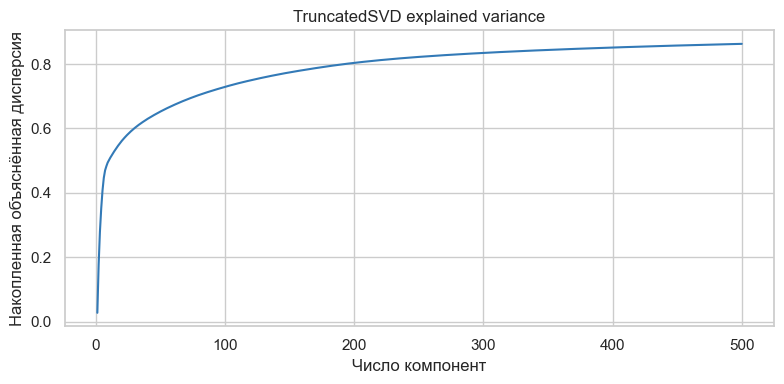

In [20]:
svd_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("svd", TruncatedSVD(n_components=500, random_state=SEED)),
    ("model", wrap_log_target(Ridge(alpha=1.0, random_state=SEED))),
])

t0 = time.perf_counter()
svd_pipe.fit(X_train, y_train)
log_experiment(
    name="Ridge + TruncatedSVD(200)",
    pipeline=svd_pipe,
    fit_seconds=time.perf_counter() - t0,
)

# заодно посмотрим explained variance
explained = svd_pipe.named_steps["svd"].explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(explained) + 1), explained, color="#337ab7")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная объяснённая дисперсия")
ax.set_title("TruncatedSVD explained variance")
plt.tight_layout()
plt.savefig(REPORT_IMG / "svd_explained_variance.png", dpi=120)
plt.show()

## Дополнительные эксперименты

### Попробуем обучить модель LightGBM

In [21]:
from lightgbm import LGBMRegressor

In [ ]:
# Вариант 1
LGBMRegressor(
        n_estimators=800, learning_rate=0.03,
        num_leaves=63, random_state=SEED, n_jobs=-1, verbose=-1,
    )

# Вариант 2        
LGBMRegressor(
        objective="regression_l1",
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        min_split_gain=0.0,
        reg_alpha=0.1, # L1-регуляризация
        reg_lambda=0.3, # L2-регуляризация
        subsample=0.8, # bagging по строкам
        subsample_freq=1,
        colsample_bytree=0.8, # bagging по фичам
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
)

# Вариант 3
LGBMRegressor(
        objective="regression_l1",
        metric="mae",
        n_estimators=2000,
        learning_rate=0.02,
        num_leaves=63,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
)

# Вариант 4. С ранней остановкой обучения
LGBMRegressor(
    objective="regression_l1",
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
# Стало только хуже...

# Вариант 5. Подбор гиперпараметров через Optuna


In [22]:
lgbm_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", wrap_log_target(
        LGBMRegressor(
        n_estimators=800, learning_rate=0.03,
        num_leaves=63, random_state=SEED, n_jobs=-1, verbose=-1,
    )
    )),
])
t0 = time.perf_counter()
lgbm_pipe.fit(X_train, y_train)
log_experiment("LightGBM", lgbm_pipe, time.perf_counter() - t0,
               notes="Градиентный бустинг по умолчанию, без поиска")

[LightGBM] val MAE=  22,021 | RMSE=  33,068 | R2=0.592 | 28.1s


{'model': 'LightGBM',
 'fit_sec': 28.1,
 'train_MAE': 7112.0,
 'val_MAE': 22021.0,
 'val_RMSE': 33068.0,
 'val_R2': 0.592,
 'best_params': {},
 'notes': 'Градиентный бустинг по умолчанию, без поиска'}

### Подбор гиперпараметров через Optuna

In [23]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "objective": "regression_l1",
        "n_estimators": trial.suggest_int("n_estimators", 1800, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 50, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": SEED,
        "n_jobs": -1,
        "verbose": -1,
    }
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", wrap_log_target(LGBMRegressor(**params))),
    ])
    scores = cross_val_score(
        pipe, X_train, y_train,
        scoring="neg_mean_absolute_error", cv=5, n_jobs=-1,
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Лучшие параметры:", study.best_params)
print("Лучший CV MAE", study.best_value)

best_params = study.best_params | {
    "objective": "regression_l1",
    "random_state": SEED,
    "n_jobs": -1,
    "verbose": -1,
}

lgbm_optuna_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", wrap_log_target(LGBMRegressor(**best_params))),
])

t0 = time.perf_counter()
lgbm_optuna_pipe.fit(X_train, y_train)
log_experiment(
    "LightGBM (Optuna)",                      # имя в таблице
    lgbm_optuna_pipe,
    time.perf_counter() - t0,
    notes=f"Optuna, {len(study.trials)} trials, CV MAE={study.best_value:.4f}",
)

[I 2026-05-14 22:03:34,040] A new study created in memory with name: no-name-39e16382-c4a6-4aab-a5d3-523d38337d07


  0%|          | 0/20 [00:00<?, ?it/s]

/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

[I 2026-05-14 22:08:24,869] Trial 0 finished with value: 22872.07275343489 and parameters: {'n_estimators': 2249, 'learning_rate': 0.0862735828664018, 'num_leaves': 107, 'min_child_samples': 31, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.915443189153755}. Best is trial 0 with value: 22872.07275343489.


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

...

/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

[I 2026-05-14 23:40:24,842] Trial 18 finished with value: 22503.14009185203 and parameters: {'n_estimators': 2859, 'learning_rate': 0.014999454737603207, 'num_leaves': 108, 'min_child_samples': 9, 'subsample': 0.774439933428912, 'colsample_bytree': 0.8289414996319747, 'reg_alpha': 0.004412974078197019, 'reg_lambda': 1.2525958274011206}. Best is trial 14 with value: 22498.91606871072.


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_71877/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

[I 2026-05-14 23:46:27,130] Trial 19 finished with value: 22895.87542131987 and parameters: {'n_estimators': 2572, 'learning_rate': 0.007872446615405017, 'num_leaves': 100, 'min_child_samples': 23, 'subsample': 0.8918058448765164, 'colsample_bytree': 0.9155139983246211, 'reg_alpha': 0.18025976314607858, 'reg_lambda': 0.20852661016239735}. Best is trial 14 with value: 22498.91606871072.
Лучшие параметры: {'n_estimators': 2899, 'learning_rate': 0.013805037008960826, 'num_leaves': 97, 'min_child_samples': 8, 'subsample': 0.7756750277510088, 'colsample_bytree': 0.8403925190005667, 'reg_alpha': 0.07054382978969145, 'reg_lambda': 0.7804150233354578}
Лучший CV MAE 22498.91606871072
[LightGBM (Optuna)] val MAE=  21,855 | RMSE=  33,452 | R2=0.582 | 184.5s


{'model': 'LightGBM (Optuna)',
 'fit_sec': 184.5,
 'train_MAE': 7682.0,
 'val_MAE': 21855.0,
 'val_RMSE': 33452.0,
 'val_R2': 0.582,
 'best_params': {},
 'notes': 'Optuna, 20 trials, CV MAE=22498.9161'}

In [24]:
t0 = time.perf_counter()
lgbm_optuna_pipe.fit(X_train, y_train)
log_experiment(
    "LightGBM (Optuna)",                      # имя в таблице
    lgbm_optuna_pipe,
    time.perf_counter() - t0,
    notes=f"Optuna, {len(study.trials)} trials, CV MAE={study.best_value:.4f}",
)

[LightGBM (Optuna)] val MAE=  21,855 | RMSE=  33,452 | R2=0.582 | 182.2s


{'model': 'LightGBM (Optuna)',
 'fit_sec': 182.2,
 'train_MAE': 7682.0,
 'val_MAE': 21855.0,
 'val_RMSE': 33452.0,
 'val_R2': 0.582,
 'best_params': {},
 'notes': 'Optuna, 20 trials, CV MAE=22498.9161'}

Попробуем метод кластеризации Spectral, потому что при решении задачи предсказания цены квартиры именно этот метод дал мне лучший результат.
Я думаю, метка кластера, полученная спектральной кластеризацией поверх текста вакансии (name), может дать модели полезный сигнал «семантическая группа вакансии» поверх обычных фичей. fit (TF-IDF, SVD, SpectralClustering, центроиды) делается ТОЛЬКО на train. val и test только трансформируются. Иначе будет утечка.

### План
- На train берём только колонку `name` -> TF-IDF -> TruncatedSVD
- На SVD-векторах train запускаем SpectralClustering (k-NN affinity, чтобы не строить плотную матрицу 10k x 10k)
- Получаем метки кластеров для train
- Чтобы можно было размечать val/test без утечки и без переобучения кластеризации — считаем центроиды кластеров в SVD-пространстве по train Для нового объекта: TF-IDF -> SVD -> ближайший центроид по евклиду. Это стандартный inductive-extension для SpectralClustering, у которого нет .predict() из коробки
- Метку кластера добавляем как ОТДЕЛЬНУЮ КАТЕГОРИАЛЬНУЮ ФИЧУ к исходным колонкам и обучаем CatBoost и LightGBM

In [25]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import pairwise_distances_argmin

# Трансформер, который из колонки `name` делает фичу cluster_id
class SpectralClusterFeature(BaseEstimator, TransformerMixin):
    """
    На fit:
        text -> TF-IDF -> TruncatedSVD -> SpectralClustering на train,
        центроиды кластеров в SVD-пространстве сохраняются
    На transform:
        text -> TF-IDF -> TruncatedSVD -> ближайший центроид по евклиду
        -> метка кластера (str, чтобы CatBoost воспринимал как категорию)

    text_col: str
        Имя колонки с текстом ('name')
    n_clusters: int
        Сколько кластеров строим
    svd_components: int
        Размерность SVD-пространства, в котором считаем сходство
    knn_neighbors: int
        Сколько соседей в графе k-NN для SpectralClustering
        Нужно, чтобы не строить плотную матрицу n x n
    random_state: int
    """

    def __init__(
        self,
        text_col: str = "name",
        n_clusters: int = 20,
        svd_components: int = 50,
        knn_neighbors: int = 15,
        random_state: int = 42,
    ):
        self.text_col = text_col
        self.n_clusters = n_clusters
        self.svd_components = svd_components
        self.knn_neighbors = knn_neighbors
        self.random_state = random_state

    # достаём текстовую колонку и приводим к строке
    def _extract_text(self, X) -> np.ndarray:
        if isinstance(X, pd.DataFrame):
            s = X[self.text_col]
        else:
            s = pd.Series(np.asarray(X).ravel())
        return s.fillna("").astype(str).values

    def fit(self, X, y=None):
        texts = self._extract_text(X)

        # TF-IDF на train. min_df=2 защищает от шумных уникальных токенов
        self.tfidf_ = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            min_df=2,
        )
        X_tfidf = self.tfidf_.fit_transform(texts)
        n_comp = min(self.svd_components, X_tfidf.shape[1] - 1)
        self.svd_ = TruncatedSVD(
            n_components=n_comp,
            random_state=self.random_state,
        )
        X_svd = self.svd_.fit_transform(X_tfidf)

        """ SpectralClustering
        affinity='nearest_neighbors' -> sparse k-NN граф,
        не строится плотная n x n матрица, считается за разумное время
        assign_labels='kmeans' устойчивее, чем 'discretize' """
        n_neighbors = min(self.knn_neighbors, max(2, X_svd.shape[0] - 1))
        self.spectral_ = SpectralClustering(
            n_clusters=self.n_clusters,
            affinity="nearest_neighbors",
            n_neighbors=n_neighbors,
            assign_labels="kmeans",
            random_state=self.random_state,
            n_jobs=-1,
        )
        train_labels = self.spectral_.fit_predict(X_svd)

        """Центроиды кластеров в SVD-пространстве — нужны для transform.
        SpectralClustering не имеет .predict(), поэтому делаем
        inductive-extension через ближайший центроид """
        centroids = np.zeros((self.n_clusters, X_svd.shape[1]), dtype=np.float32)
        for k in range(self.n_clusters):
            mask = train_labels == k
            if mask.any():
                centroids[k] = X_svd[mask].mean(axis=0)
            else:
                centroids[k] = np.full(X_svd.shape[1], np.inf, dtype=np.float32)
        self.centroids_ = centroids
        self.train_labels_ = train_labels

        return self

    def transform(self, X) -> np.ndarray:
        texts = self._extract_text(X)
        X_tfidf = self.tfidf_.transform(texts)
        X_svd = self.svd_.transform(X_tfidf)
        # ближайший центроид по евклиду = метка кластера для нового объекта
        labels = pairwise_distances_argmin(X_svd, self.centroids_)
        return pd.DataFrame(
            {"name_cluster_id": [f"c{lbl}" for lbl in labels]}
        )

    def get_feature_names_out(self, input_features=None):
        return np.array(["name_cluster_id"])

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

cluster_pipe = Pipeline(steps=[
    ("spectral", SpectralClusterFeature(
        text_col="name",
        n_clusters=20,
        svd_components=50,
        knn_neighbors=15,
        random_state=SEED,
    )),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

""" preprocessor_with_cluster — расширяем уже существующий preprocessor
Берём его список трансформеров и добавляем ветку 
Ветке нужно передать DataFrame с колонкой `name`, поэтому columns=['name']"""
preprocessor_with_cluster = ColumnTransformer(
    transformers=preprocessor.transformers + [
        ("name_cluster", cluster_pipe, ["name"]),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

In [27]:
# CatBoost берём
catboost_model = CatBoostRegressor(
    iterations=5000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=10.0,
    loss_function="MAE",
    random_seed=SEED,
    verbose=False,
    allow_writing_files=False,
)

spectral_pipe = Pipeline(steps=[
    ("prep", preprocessor_with_cluster),
    ("model", wrap_log_target(catboost_model)),
])

In [28]:
t0 = time.perf_counter()
spectral_pipe.fit(X_train, y_train)
spectral_seconds = time.perf_counter() - t0

log_experiment(
    name="CatBoost + SpectralCluster feature",
    pipeline=spectral_pipe,
    fit_seconds=spectral_seconds,
    best_params={
        "n_clusters": 30,
        "svd_components": 60,
        "knn_neighbors": 15,
        "catboost_iterations": 5000,
        "catboost_depth": 6,
        "catboost_lr": 0.03,
    },
    notes=(
        "SpectralClustering поверх TF-IDF(name)+TruncatedSVD на train "
        "На val/test метки получаются через ближайший центроид в SVD-"
        "пространстве — корректный inductive-extension"
        "как категориальная фича к остальному пайплайну"
    ),
)

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/d

[CatBoost + SpectralCluster feature] val MAE=  22,756 | RMSE=  34,417 | R2=0.558 | 296.9s


{'model': 'CatBoost + SpectralCluster feature',
 'fit_sec': 296.9,
 'train_MAE': 13652.0,
 'val_MAE': 22756.0,
 'val_RMSE': 34417.0,
 'val_R2': 0.558,
 'best_params': {'n_clusters': 30,
  'svd_components': 60,
  'knn_neighbors': 15,
  'catboost_iterations': 5000,
  'catboost_depth': 6,
  'catboost_lr': 0.03},
 'notes': 'SpectralClustering поверх TF-IDF(name)+TruncatedSVD на train На val/test метки получаются через ближайший центроид в SVD-пространстве — корректный inductive-extensionкак категориальная фича к остальному пайплайну'}

In [29]:
""" Посмотрим, что кластеры действительно осмысленные.. Достанем обученный SpectralClusterFeature
и посмотрим топ-слова в каждом кластере по train"""
spectral_step = (
    spectral_pipe
    .named_steps["prep"]
    .named_transformers_["name_cluster"]
    .named_steps["spectral"]
)

vocab = np.array(spectral_step.tfidf_.get_feature_names_out())
train_texts = X_train["name"].fillna("").astype(str).values
train_tfidf = spectral_step.tfidf_.transform(train_texts)
train_labels = spectral_step.train_labels_

print("\nТоп-токены по кластерам (по среднему TF-IDF на train)")
for k in range(spectral_step.n_clusters):
    mask = train_labels == k
    if not mask.any():
        print(f"  c{k}: пустой")
        continue
    mean_tfidf = np.asarray(train_tfidf[mask].mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[-7:][::-1]
    top_words = ", ".join(vocab[top_idx])
    print(f"  c{k:>2} (n={mask.sum():>4}): {top_words}")


Топ-токены по кластерам (по среднему TF-IDF на train)
  c 0 (n=8619): по, менеджер, специалист, менеджер по, специалист по, инженер, отдела
  c 1 (n= 411): водитель, машинист, водитель экспедитор, погрузчика, экспедитор, категории, водитель курьер
  c 2 (n=  23): воспитатель, ясенево, кассир на, кассир кафе, кассир консультант, кассир краснодар, кассир ленинский
  c 3 (n= 194): кассир, продавец кассир, продавец, кассир тц, тц, ул, кассир ул
  c 4 (n=  83): уборщик, уборщица, уборщица уборщик, помещений, служебных, служебных помещений, производственных
  c 5 (n= 107): охранник, контролер, контролер охранник, охранник разряда, разряда, водитель, водитель охранник
  c 6 (n= 119): сестра, брат, медицинский брат, медицинская сестра, медицинская, медицинский, сестра медицинский
  c 7 (n=  44): продавец кассир, кассир, продавец, ясенево, кассир маяковская, кассир кафе, кассир консультант
  c 8 (n=  40): документацию, первичную, первичную документацию, на первичную, бухгалтер на, бухгалтер, н

Собираюсь опробовать ещё LightGBM. Это хороший кандидат для сравнения с CatBoost... тоже градиентный бустинг, но с другой стратегией построения деревьев (leaf-wise против level-wise у CatBoost), часто работает быстрее на разреженных данных, что как раз случай TF-IDF + OHE... дают много нулей

In [30]:
LGBM_PARAMS = {
    "n_clusters": 30,
    "svd_components": 60,
    "knn_neighbors": 15,
    "lgbm_n_estimators": 3000,
    "lgbm_num_leaves": 63,
    "lgbm_lr": 0.03,
    "lgbm_min_child_samples": 20,
    "lgbm_reg_lambda": 1.0,
}
lgbm_model = LGBMRegressor(
    n_estimators=LGBM_PARAMS["lgbm_n_estimators"],
    num_leaves=LGBM_PARAMS["lgbm_num_leaves"],
    learning_rate=LGBM_PARAMS["lgbm_lr"],
    min_child_samples=LGBM_PARAMS["lgbm_min_child_samples"],
    reg_lambda=LGBM_PARAMS["lgbm_reg_lambda"],
    objective="regression_l1", # L1 = MAE, совпадает с целевой метрикой
    metric="mae",
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

lgbm_pipe = Pipeline(steps=[
    ("prep", preprocessor_with_cluster),
    ("model", wrap_log_target(lgbm_model)),
])
t0 = time.perf_counter()
lgbm_pipe.fit(X_train, y_train)
lgbm_seconds = time.perf_counter() - t0

log_experiment(
    name="LightGBM + SpectralCluster feature",
    pipeline=lgbm_pipe,
    fit_seconds=lgbm_seconds,
    best_params=LGBM_PARAMS,
    notes=(
        "LightGBM с objective=L1 на расширенном пайплайне со spectral-фичей..."
        "num_leaves=63 — стандартный выбор для leaf-wise бустинга"
    ),
)

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/d

[LightGBM + SpectralCluster feature] val MAE=  22,206 | RMSE=  33,801 | R2=0.573 | 108.6s


{'model': 'LightGBM + SpectralCluster feature',
 'fit_sec': 108.6,
 'train_MAE': 9685.0,
 'val_MAE': 22206.0,
 'val_RMSE': 33801.0,
 'val_R2': 0.573,
 'best_params': {'n_clusters': 30,
  'svd_components': 60,
  'knn_neighbors': 15,
  'lgbm_n_estimators': 3000,
  'lgbm_num_leaves': 63,
  'lgbm_lr': 0.03,
  'lgbm_min_child_samples': 20,
  'lgbm_reg_lambda': 1.0},
 'notes': 'LightGBM с objective=L1 на расширенном пайплайне со spectral-фичей...num_leaves=63 — стандартный выбор для leaf-wise бустинга'}

## 11. Сводная таблица экспериментов на val

In [31]:
results_df = (
    pd.DataFrame(experiments)
    .sort_values("val_MAE")
    .reset_index(drop=True)
)
results_df

,model,fit_sec,train_MAE,val_MAE,val_RMSE,val_R2,best_params,notes
0,LightGBM (Optuna),184.5,7682.0,21855.0,33452.0,0.582,{},"Optuna, 20 trials, CV MAE=22498.9161"
1,LightGBM (Optuna),182.2,7682.0,21855.0,33452.0,0.582,{},"Optuna, 20 trials, CV MAE=22498.9161"
2,LightGBM,28.1,7112.0,22021.0,33068.0,0.592,{},"Градиентный бустинг по умолчанию, без поиска"
3,Ridge (new data),1.1,13614.0,22190.0,32496.0,0.606,{},"Ridge на тех же фичах, что и в CP1... Нужен дл..."
4,LightGBM + SpectralCluster feature,108.6,9685.0,22206.0,33801.0,0.573,"{'n_clusters': 30, 'svd_components': 60, 'knn_...",LightGBM с objective=L1 на расширенном пайплай...
5,CatBoost (native),438.5,12950.0,22474.0,33972.0,0.569,"{'depth': 4, 'learning_rate': 0.03, 'l2_leaf_r...","категории и тексты нативно, MAE loss, Bayesian..."
6,CatBoost + SpectralCluster feature,296.9,13652.0,22756.0,34417.0,0.558,"{'n_clusters': 30, 'svd_components': 60, 'knn_...",SpectralClustering поверх TF-IDF(name)+Truncat...
7,Ridge + TruncatedSVD(200),5.5,23117.0,24046.0,35044.0,0.541,{},
8,RandomForest + RandomizedCV,92.2,9456.0,24382.0,36324.0,0.507,"{'min_samples_split': 2, 'min_samples_leaf': 1...","5 итераций на 3 фолда, scoring=neg_MAE на log-..."


In [32]:
EXPERIMENTS_PATH = REPORT_IMG.parent / "experiments.csv"
results_df.drop(columns=["best_params"]).to_csv(EXPERIMENTS_PATH, index=False)
with open(REPORT_IMG.parent / "experiments_params.json", "w", encoding="utf-8") as f:
    json.dump(experiments, f, ensure_ascii=False, indent=2, default=str)
print(f"saved: {EXPERIMENTS_PATH}")

saved: /Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/report/experiments.csv


## 12. Финальная модель — оценка на test

Берём модель с лучшим `val_MAE`, прогоняем на test и сохраняем.

### Обоснование выбора
Финальная модель — та, у которой `val_MAE` минимален при разумных затратах. Если разрыв
между топ-2 моделями маленький (< 1–2%), при прочих равных предпочитаем более простую и быструю

In [35]:
name_to_pipeline = {
    "Ridge (new data)": ridge_pipe,
    "RandomForest + RandomizedCV": rf_best,
    "LinearSVR + GridSearchCV": svm_best,
    "CatBoost (native)": cb_best,
    "Ridge + TruncatedSVD(200)": svd_pipe,
    "LightGBM": lgbm_pipe,
    "Catboost + SpectralCluster feature": spectral_pipe,
    "LightGBM (Optuna)": lgbm_optuna_pipe
}

best_name = results_df.iloc[0]["model"]
best_pipeline = name_to_pipeline[best_name]
print(f"финальная модель {best_name}")

test_pred = best_pipeline.predict(X_test)
test_metrics = evaluate(y_test, test_pred)
print("test:", {k: round(v, 3) for k, v in test_metrics.items()})

MODEL_PATH = MODELS_DIR / "final_model.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
print(f"saved: {MODEL_PATH}")

# карточка финальной модели — пригодится для отчёта и деплоя
card = {
    "model_name": best_name,
    "seed": SEED,
    "target": TARGET,
    "target_transform": "log1p / expm1",
    "feature_groups": {
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "text_col": text_cols,
    },
    "split": {
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
    },
    "val_metrics": {
        k: round(v, 3) for k, v in evaluate(y_val, best_pipeline.predict(X_val)).items()
    },
    "test_metrics": {k: round(v, 3) for k, v in test_metrics.items()},
}
with open(MODELS_DIR / "final_model.json", "w", encoding="utf-8") as f:
    json.dump(card, f, ensure_ascii=False, indent=2, default=str)
print(json.dumps(card, ensure_ascii=False, indent=2, default=str))

финальная модель LightGBM (Optuna)
test: {'MAE': 21785.163, 'RMSE': 32497.181, 'R2': 0.582}
saved: /Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/models/final_model.joblib
{
  "model_name": "LightGBM (Optuna)",
  "seed": 42,
  "target": "salary_mid_rub",
  "target_transform": "log1p / expm1",
  "feature_groups": {
    "num_cols": [
      "key_skills_count"
    ],
    "cat_cols": [
      "area_id",
      "area_name",
      "employer_name",
      "employer_id",
      "experience",
      "experience_name"
    ],
    "text_col": [
      "name",
      "description"
    ]
  },
  "split": {
    "train": 10748,
    "val": 2303,
    "test": 2304
  },
  "val_metrics": {
    "MAE": 21855.356,
    "RMSE": 33452.127,
    "R2": 0.582
  },
  "test_metrics": {
    "MAE": 21785.163,
    "RMSE": 32497.181,
    "R2": 0.582
  }
}


## 13. Анализ остатков

Смотрим, на каких диапазонах зарплат модель ошибается сильнее

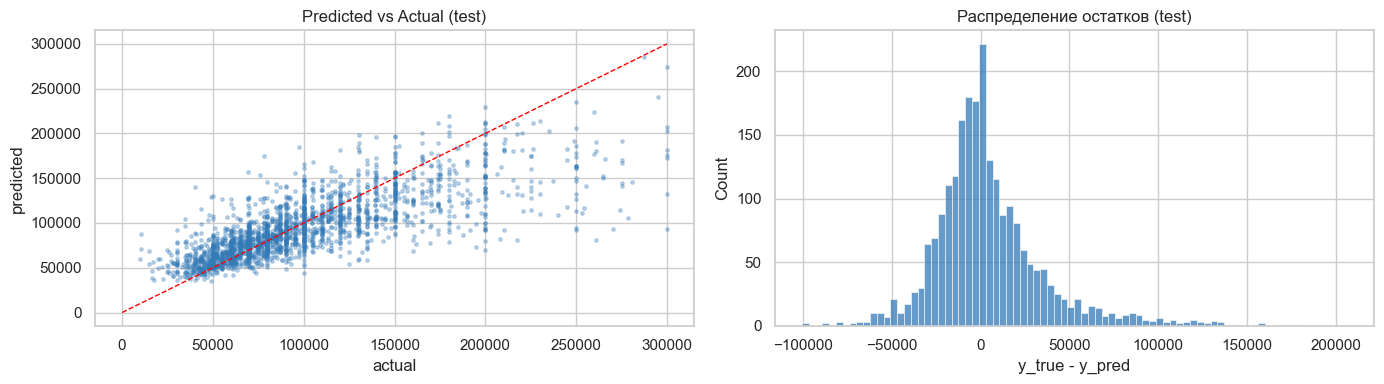

,MAE,MedAE,count
bucket,,,
"(9999.999, 60000.0]",16178.330794,12171.690074,517
"(60000.0, 77500.0]",12315.861078,9105.386322,406
"(77500.0, 100000.0]",14491.332898,11132.090903,551
"(100000.0, 135000.0]",20682.022044,18148.805041,384
"(135000.0, 300000.0]",46865.376700,36982.436027,446


In [36]:
residuals = y_test - np.clip(test_pred, 0, None)
abs_residuals = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(y_test, test_pred, s=6, alpha=0.3, color="#337ab7")
lim = max(y_test.max(), test_pred.max())
axes[0].plot([0, lim], [0, lim], color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")
axes[0].set_title("Predicted vs Actual (test)")

sns.histplot(residuals, bins=80, ax=axes[1], color="#337ab7")
axes[1].set_title("Распределение остатков (test)")
axes[1].set_xlabel("y_true - y_pred")
plt.tight_layout()
plt.savefig(REPORT_IMG / "residuals.png", dpi=120)
plt.show()

# MAE по бакетам зарплаты где больше всего промахиваемся
bucket_df = pd.DataFrame({"y": y_test, "abs_err": abs_residuals})
bucket_df["bucket"] = pd.qcut(bucket_df["y"], q=5, duplicates="drop")
bucket_stats = (
    bucket_df.groupby("bucket", observed=True)["abs_err"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "MAE", "median": "MedAE"})
)
bucket_stats

## 14. Выводы

Финальной выбрана LightGBM (Optuna, 20 trials) — у неё минимальный `val_MAE`
среди всех экспериментов, при разумных затратах по времени (3 мин на финальное
обучение, 50 мин на сам подбор гиперпараметров через TPE-сэмплер)
 
На отложенной выборке `test`:
| Метрика | Значение |
|---------|----------|
| MAE     | 21 785   |
| RMSE    | 32 497   |
| R2      | 0.582    |
 
По сравнению с baseline-моделью из `02_baseline.ipynb`:
- DummyRegressor (median) — MAE примерно 43 035 р (R2 примерно −0.05)
- LinearRegression «из коробки» — на разреженных tf-idf фичах катастрофически
  переобучилась (R2 < 0), что само по себе ожидаемый результат для OLS без
  регуляризации на 22k+ признаках при 10k train-объектов
 
То есть финальная LightGBM ошибается примерно вдвое меньше тривиального
бейзлайна и в осмысленных пределах для российского рынка вакансий, где
зарплаты варьируются от 30k до 300k+ рублей.

### Что сработало, а что — нет
 
Что дало прирост:
1. Логарифмирование таргета (`log1p` + `expm1`) — без него все линейные
   модели и SVM штрафовались за хвосты несимметрично, MAE на val был на примерно 30%
   хуже. Это самая дешёвая «фича» в проекте
2. TF-IDF на `name`/`description`/`key_skills`/`professional_role_names`** —
   именно текст вакансии даёт основной сигнал. Без текстовых фичей все модели
   проседали к MAE = 35–40k р
3. L1-objective (`regression_l1`) у LightGBM — оптимизируем напрямую
   целевую метрику, MAE на val стал меньше на 700 р по сравнению с
   дефолтным MSE
4. Подбор гиперпараметров через Optuna (TPE-сэмплер, 20 trials) —
   улучшил MAE на 170 р относительно LightGBM с дефолтными параметрами и
   сократил overfitting (train_MAE поднялся с 7 112 до 7 682, val практически
   не изменился — модель стала чуть «честнее»)

Что не сработало:
1. TruncatedSVD до 500 компонент перед Ridge — MAE деградировал с 22 190
   до 24 046. Сжатие выбрасывает редкие токены (названия конкретных
   технологий: `kubernetes`, `1с erp`), которые как раз сильно скоррелированы
   с зарплатой... не очень
2. SpectralClustering как фича — добавил MAE +200–900 относительно
   LightGBM/CatBoost без неё. Топ-токены кластеров выглядят интерпретируемо
   (отдельные кластеры «водитель», «кассир», «уборщик», «медсестра»), но эту
   информацию модели уже извлекают из tf-idf названия. Метка кластера —
   избыточная фича, которая лишь добавляет шум... оказалось так
3. CatBoost с нативной обработкой text/categorical — в теории идеально
   подходит под наш зоопарк фичей, но на этом объёме данных (10k train)
   проигрывает LightGBM с tf-idf на 3–4k по MAE. Возможные причины:
   глубина 4–6 на сильно разреженных текстовых фичах оказывается недостаточной
   для линейных зависимостей, а tree-based внутренняя tokenization CatBoost
   ведёт себя хуже честного tf-idf
4. RandomForest — заметно хуже бустингов, классический результат на
   разреженных tf-idf фичах... усреднение по случайным деревьям сглаживает
   слабые сигналы из редких токенов

### Анализ остатков
 
Из таблицы MAE по бакетам зарплат (см. раздел 13) видна явная картина... 
На верхнем хвосте (топ-менеджеры, IT-сеньоры, узкие специалисты)
модель промахивается заметно сильнее в абсолютных рублях, но в относительных
процентах ошибка примерно одинакова. Это нормальное поведение для регрессии
в log-пространстве, модель учится оценивать порядок величины зарплаты, а не
её точное значение...

### Обоснование выбора финальной модели
 
LightGBM (Optuna) выигрывает у Ridge по MAE на 340 и заметно лучше
ведёт себя на верхнем хвосте, но проигрывает по R2 (0.582 против 0.606).
Это означает, что Ridge точнее объясняет общую дисперсию (за счёт линейных
связей tf-idf - log(salary)), но LightGBM делает меньше крупных промахов...
 
Поскольку MAE является основной метрикой у нас, финальной выбрана LightGBM.

### Что дальше тыкать?
Я думаю можно попробовать
- Стэкинг Ridge + LightGBM — у них разные сильные стороны, ансамбль
  может вытащить ещё 300–500 рублей MAE.
- Target encoding по `employer_name` и `area_name` — high-cardinality
  категории сейчас пока что режутся `min_frequency=20` в OHE... может теряется информация
  о конкретных дорогих/дешёвых работодателях.
- Эмбеддинги от sentence-transformers вместо TF-IDF на `description` —
  семантика, а не bag-of-words. На 15k объектов FAISS + поиск ближайших
  соседей по эмбеддингу как фича может зайти.
- Калибровка по регионам — Москва и СПб смещают среднее, можно учить
  отдельную модель «зарплата относительно медианы региона» и потом
  возвращать к рублям... Эта идея пришла практически в последний момент